# <span style='color:#66c2a5'>**Introduction**</span>

This is the UCI Heart Disease dfset.

We have many files in the folder:

- `cleveland.df`, `hungarian.df`, `switzerland.df`, `long-beach-va.df` → the raw heart disease dfsets from 4 hospitals.

- `processed.cleveland.df`, `processed.hungarian.df`, `processed.switzerland.df`, `processed.va.df` → cleaned/processed versions of the above.

- `heart-disease.names` → description of columns (like a df dictionary).

- `reprocessed.hungarian.df` → another processed variant.

- `new.df` → likely an aggregated or test dfset.

We'll use `processed.cleveland.df` — it’s the most commonly used version in research and tutorials.

- It contains 14 attributes (columns).

- The last column is the target (disease presence: 0 = no, 1-4 = levels of heart disease).

- we'll need `heart-disease.names` to understand what each column means.

# <span style='color:#fc8d62'>**Loading the data**</span>

In [2]:
# Importing libraries 
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Convert interactive plots to PNG format for GitHub rendering
import plotly.io as pio
pio.renderers.default = "png"

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the processed Cleveland dfset
col_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]
 
data = pd.read_csv("./heart_disease/processed.cleveland.data",names=col_names)
df = data.copy()

In [4]:
df.sample(20)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
257,76.0,0.0,3.0,140.0,197.0,0.0,1.0,116.0,0.0,1.1,2.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
252,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,0
177,56.0,1.0,4.0,132.0,184.0,0.0,2.0,105.0,1.0,2.1,2.0,1.0,6.0,1
23,58.0,1.0,3.0,132.0,224.0,0.0,2.0,173.0,0.0,3.2,1.0,2.0,7.0,3
205,45.0,1.0,4.0,142.0,309.0,0.0,2.0,147.0,1.0,0.0,2.0,3.0,7.0,3
278,57.0,1.0,2.0,154.0,232.0,0.0,2.0,164.0,0.0,0.0,1.0,1.0,3.0,1
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0
45,58.0,1.0,3.0,112.0,230.0,0.0,2.0,165.0,0.0,2.5,2.0,1.0,7.0,4
136,70.0,1.0,4.0,145.0,174.0,0.0,0.0,125.0,1.0,2.6,3.0,0.0,7.0,4


# <span style='color:#8da0cb'>**Data Cleaning**</span>

In [5]:
# Duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
# Replace "?" with NaN
df.replace("?", pd.NA, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [8]:
# All columns have numerical values
df = df.apply(pd.to_numeric)

In [9]:
# Check for missing values
df.isna().sum().nlargest(10)

ca          4
thal        2
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
dtype: int64

In [10]:
# Target should be binary (0=no disease, 1-4=disease presence with severity)
# Convert to binary
df["target_binary"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

In [11]:
# Adding labels for categorical columns

# Sex
df['sex_label'] = df['sex'].map({0:'Female', 1:'Male'})

# Disease status
df['disease_status'] = df['target_binary'].map({0: 'No Disease', 1: 'Disease'})

# chest pain type
cp_labels = {1: 'typical angina', 2: 'atypical angina', 3: 'non-anginal pain', 4: 'asymptomatic'}
df['cp_label'] = df['cp'].map(cp_labels)

# Exercise induced angina
df['exang_label'] = df['exang'].map({0: 'No', 1: 'Yes'})

# The slope of the peak exercise ST segment
slope_labels = {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'}
df['slope_label'] = df['slope'].map(slope_labels)

# Fasting blood sugar  > 120 mg/dl
df['fbs_label'] = df['fbs'].map({0: 'Normal', 1: 'High'})

# Gender & Disease Status 
df['gender_disease'] = df['sex_label'] + " - " + df['disease_status']


# <span style='color:#e78ac3'>**Exploratory Data Analysis**</span>

### <span style='color:#b3b3b3'>**General overview**</span>

In [12]:
# Number of patients
df.shape[0]

303

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [14]:
# Percentage of patients having heart disease
heart_disease_percent = ((df['target']>0).sum() * 100 ) / df.shape[0]
print(f"Percentage of patients with heart disease: {heart_disease_percent:.2f}%")

Percentage of patients with heart disease: 45.87%


In [15]:
# Average cholesterol by disease presence
print(df.groupby("target_binary")["chol"].mean())

target_binary
0    242.640244
1    251.474820
Name: chol, dtype: float64


In [16]:
# Average age by disease presence
print(df.groupby("target_binary")["age"].mean())

target_binary
0    52.585366
1    56.625899
Name: age, dtype: float64


In [17]:
# Average age of patients
avg_age = df['age'].mean()
print(f"\nAverage age of all patients: {avg_age:.2f} years")



Average age of all patients: 54.44 years


### <span style='color:#b3b3b3'>**Target variable (Disease Status)**</span>

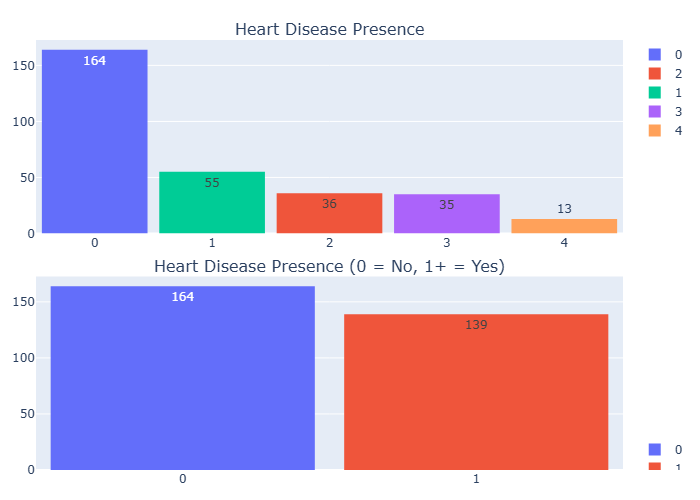

In [18]:
fig = make_subplots(rows=2, cols=1, 
                    subplot_titles=("Heart Disease Presence", 
                                   "Heart Disease Presence (0 = No, 1+ = Yes)"),
                    vertical_spacing=0.1)

# Distribution of target variable
fig1 = px.histogram(df, x='target', color='target', nbins=5, 
                   text_auto=True)

# Simplify target: 0 = no disease, 1 = disease (1–4 levels)
fig2 = px.histogram(df, x="target_binary", color="target_binary", 
                   text_auto=True)

for trace in fig1.data:
    trace.legendgroup = "group1"
    fig.add_trace(trace, row=1, col=1)
    
for trace in fig2.data:
    trace.legendgroup = "group2"
    fig.add_trace(trace, row=2, col=1)

fig.update_layout(height=800, width=1000, bargap=0.1, 
                  margin=dict(l=20, r=20, t=40, b=30),
                  legend=dict(tracegroupgap=300))
fig.update_xaxes(tickmode='array', tickvals=[0,1,2,3,4], row=1, col=1)
fig.update_xaxes(tickmode='array', tickvals=[0,1], row=2, col=1)
fig.show()

There's a significant data imbalance with healthy cases (target=0) dominating at 55%, while disease cases (target=1-4) are distributed across severity levels, requiring careful consideration for predictive modeling.

### <span style='color:#b3b3b3'>**Gender**</span>

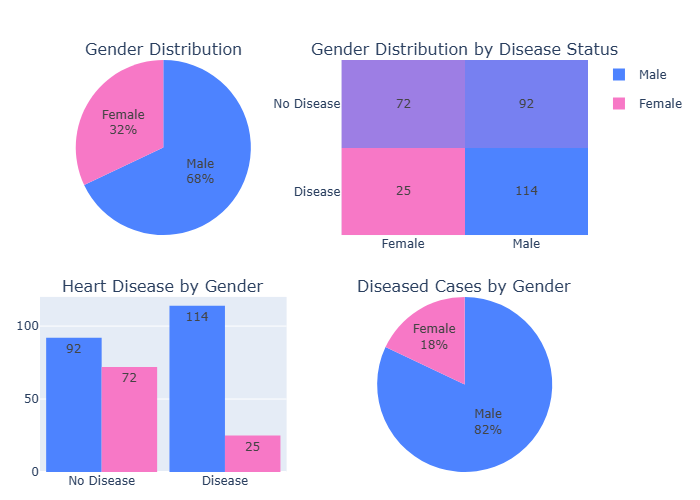

In [19]:
colors = ["#4d83ff", "#f778c6"]
sex_labels = df['sex_label'].unique().tolist()
bar_color_map = {sex_labels[0]: colors[0], sex_labels[1]: colors[1]} 
sex_disease = pd.crosstab(df['disease_status'], df['sex_label'])
disease_counts = df[df['target_binary'] == 1]['sex_label'].value_counts().reset_index()

fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=("Gender Distribution", "Gender Distribution by Disease Status",
                                    "Heart Disease by Gender", "Diseased Cases by Gender"),
                    specs=[[{"type": "pie"}, {}], [{}, {"type": "pie"}]],
                    vertical_spacing=0.15, horizontal_spacing=0.1)

# 1. Gender Pie
fig.add_trace(px.pie(df, names='sex_label')
              .update_traces(textinfo='label+percent', marker=dict(colors=colors), showlegend=False).data[0], row=1, col=1)

# 2. Heatmap
fig.add_trace(px.imshow(sex_disease, text_auto=True)
              .update_traces(coloraxis=None, colorscale=colors[::-1], showscale=False, showlegend=False).data[0], row=1, col=2)

# 3. Bar Chart
for t in px.histogram(df, x="disease_status", color="sex_label", barmode="group", text_auto=True,
                      color_discrete_map=bar_color_map).data:
    t.name = t.legendgroup
    fig.add_trace(t, row=2, col=1)

# 4. Diseased Pie
fig.add_trace(px.pie(disease_counts, names='sex_label', values='count')
              .update_traces(textinfo='label+percent', marker=dict(colors=colors), showlegend=False).data[0], row=2, col=2)

fig.update_layout(height=800, width=1200, bargap=0.1, margin=dict(l=40, r=20, t=60, b=20))
fig.show()

- `Males` represent 68% of the total dataset (206 patients) while `females` are only 32% (97 patients), showing a significant gender imbalance that could affect model generalization.

- `Males` show dramatically higher disease rates: 114 diseased vs 92 healthy (55% disease rate).
- `Females` show much lower disease rates: only 25 diseased vs 72 healthy (26% disease rate).
- `Males` are more than 4 times as likely to have heart disease in this dataset (114 vs 25 cases).

- Among diseased patients, `males` constitute 82% while `females` are only 18%, indicating either a genuine epidemiological pattern or potential sampling bias in the dataset that should be considered when building predictive models.

- The heatmap clearly shows the interaction effect: `male` patients have both higher absolute numbers and higher proportional disease rates, suggesting gender is likely a significant predictor variable for heart disease risk in this population.

### <span style='color:#b3b3b3'>**Chest Pain**</span>

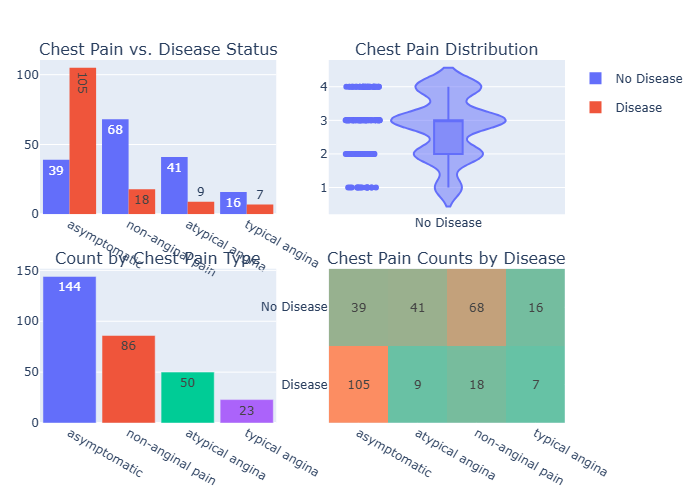

In [20]:
# Data prep
cp_order = df['cp_label'].value_counts().index.tolist()
cp_comparison = pd.crosstab(df['disease_status'], df['cp_label'])
colors = px.colors.qualitative.Set2 
violin_color = colors[0]

# Create figure
fig = make_subplots(rows=2, cols=2, subplot_titles=("Chest Pain vs. Disease Status", "Chest Pain Distribution", 
                    "Count by Chest Pain Type","Chest Pain Counts by Disease"),
                    specs=[[{}, {}], [{}, {}]],
                    horizontal_spacing=0.1, vertical_spacing=0.15)

# 1. Grouped Histogram
for t in px.histogram(df, x="cp_label", color="disease_status", barmode="group", text_auto=True).data:
    t.name = t.legendgroup
    fig.add_trace(t, row=1, col=1)

# 2. Violin Plot
fig.add_trace(px.violin(df, x="disease_status", y="cp", color="disease_status", points='all', box=True).data[0],
                   row=1, col=2)

# 3. Simple Histogram
cp_counts = df['cp_label'].value_counts().loc[cp_order].reset_index()

for trace in px.bar(cp_counts, x='cp_label', y='count', color='cp_label', text_auto=True).data:
    fig.add_trace(trace, row=2, col=1)

# 4. Heatmap
fig.add_trace(px.imshow(cp_comparison, text_auto=True)
            .update_traces(coloraxis=None, colorscale=[[0, '#66c2a5'], [1, '#fc8d62']],
                           showscale=False, showlegend=False).data[0], row=2, col=2)

# Update axes ordering
fig.update_xaxes(categoryorder='array', categoryarray=cp_order, row=1, col=1)
fig.update_xaxes(categoryorder='array', categoryarray=cp_order, row=2, col=1)
fig.update_layout(height=800, width=1200, bargap=0.1,
                  margin=dict(l=40, r=20, t=60, b=20),
                  legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02))

# Hide legend for other traces
for i, trace in enumerate(fig.data):
    if i >= 2:  # After first 2 traces (plot 1 has 2 traces for disease/no disease)
        trace.showlegend = False
fig.show()

- `Asymptomatic` chest pain (no pain) is the most common type overall (144 patients), but shows a dramatic split: 105 have disease vs only 39 are healthy. This means if someone shows no chest pain symptoms, they're actually more likely to have heart disease in this dataset.
- `Non-anginal` pain shows the opposite pattern: 68 healthy vs only 18 diseased, suggesting this type of pain is less associated with heart disease.

- The violin plot shows healthy patients cluster around pain types 2-3 (`non-anginal` and `atypical angina`), with chest pain type 3 being most common.
- Diseased patients predominantly experience type 4 (`asymptomatic`/no pain), which is counterintuitive but clinically important.

- `Typical angina` (classic heart-related chest pain) is relatively rare in this dataset (only 23 cases), with just 7 in diseased patients. This suggests that waiting for "classic" chest pain symptoms might miss many heart disease cases.

- The heatmap clearly shows that being `asymptomatic` is actually a risk factor in this population, which highlights the importance of screening beyond just chest pain symptoms for heart disease detection.

### <span style='color:#b3b3b3'>**Cholesterol**</span>

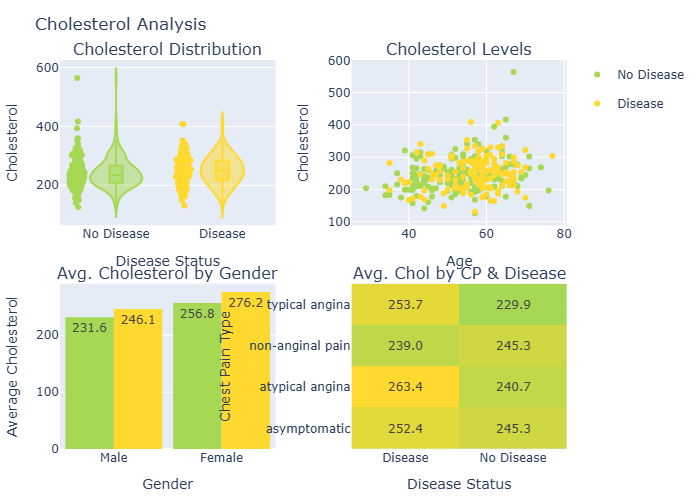

In [21]:
# 1. Data Prep for Plot 4
chol_avg = df.groupby(['cp_label', 'disease_status'])['chol'].mean().unstack().fillna(0)
colors = ['#a6d854', '#ffd92f',] 

# 2. Figure Setup
fig = make_subplots(rows=2, cols=2, subplot_titles=("Cholesterol Distribution", "Cholesterol Levels",
                    "Avg. Cholesterol by Gender", "Avg. Chol by CP & Disease"),
                    specs=[[{}, {}], [{}, {}]], horizontal_spacing=0.15, vertical_spacing=0.15)

# --- 1. Violin Plot 
for t in px.violin(df, x="disease_status", y="chol", color="disease_status", points='all', box=True, 
                   color_discrete_sequence=colors).data: 
    fig.add_trace(t.update(showlegend=False), row=1, col=1)
fig.update_xaxes(title_text="Disease Status", row=1, col=1)
fig.update_yaxes(title_text="Cholesterol", row=1, col=1)

# --- 2. Box Plot 
for t in px.scatter(df, x="age", y="chol", color="disease_status", color_discrete_sequence=colors).data: 
    fig.add_trace(t, row=1, col=2)
fig.update_xaxes(title_text="Age", row=1, col=2)
fig.update_yaxes(title_text="Cholesterol", row=1, col=2)

# --- 3. Grouped Histogram 
for t in px.histogram(df, x="sex_label", y="chol", color="disease_status", barmode="group", histfunc='avg',
                      color_discrete_sequence=colors, text_auto=True).data: 
    fig.add_trace(t.update(showlegend=False, texttemplate='%{y:.1f}'), row=2, col=1)
fig.update_xaxes(title_text="Gender", row=2, col=1)
fig.update_yaxes(title_text="Average Cholesterol", row=2, col=1)

# --- 4. Heatmap 
# FIX 2: Added showscale=False (which was already there, but ensuring it's kept clean)
fig.add_trace(px.imshow(chol_avg, text_auto=True).update_traces(coloraxis=None, colorscale=[[0, colors[0]], [1, colors[1]]],
                           showscale=False, showlegend=False, texttemplate='%{z:.1f}').data[0], row=2, col=2)
fig.update_xaxes(title_text="Disease Status", row=2, col=2)
fig.update_yaxes(title_text="Chest Pain Type", row=2, col=2)

# --- Final Layout ---
fig.update_layout(height=800, width=1200, bargap=0.1, 
                  margin=dict(l=60, r=10, t=60, b=20),
                  title_text="Cholesterol Analysis")
fig.show()

- Both healthy and diseased patients show similar `cholesterol` distributions, with most values clustering between 200-300 mg/dL. The violin plots reveal nearly identical median values (around 240-250), suggesting `cholesterol` alone may not be a strong predictor of heart disease in this dataset.
- There are some extreme outliers, with a few patients reaching 400-600 mg/dL, appearing in both groups.

- The scatter plot shows `cholesterol` levels are fairly scattered across all ages with no clear upward or downward trend. Both diseased (yellow) and healthy (green) patients have similar `cholesterol` ranges regardless of age.
- Most values concentrate in the 200-350 range across the 40-70 age span.

- Females have notably higher average `cholesterol` (276.2 diseased, 256.8 healthy) compared to males (246.1 diseased, 231.6 healthy). This approximately 20-30 point difference is consistent across disease status.
- The pattern holds true: females tend to have elevated `cholesterol` levels regardless of whether they have heart disease.

- The heatmap shows minimal variation in average `cholesterol` across different chest pain types and disease status. Values range narrowly from 229-263, suggesting `cholesterol` levels don't vary much by symptom presentation.
- All combinations fall within a similar moderate range (230-265 mg/dL).

- Surprisingly, `cholesterol` levels show little difference between healthy and diseased patients in this dataset, challenging the common assumption that high `cholesterol` strongly indicates heart disease. Gender appears more influential on `cholesterol` than disease status.

### <span style='color:#b3b3b3'>**Age**</span>

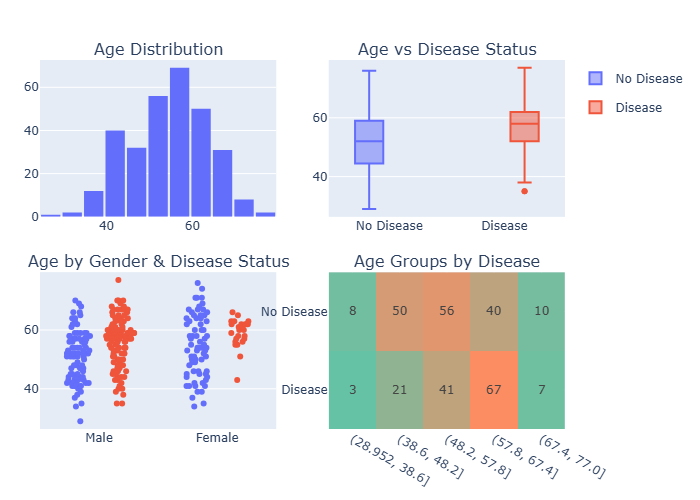

In [22]:
# Data prep
age_comparison = pd.crosstab(df['disease_status'], pd.cut(df['age'], bins=5).astype(str))

# Create figure
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=("Age Distribution", "Age vs Disease Status", 
                                    "Age by Gender & Disease Status", "Age Groups by Disease"),
                    specs=[[{}, {}], [{}, {}]],
                    horizontal_spacing=0.1, vertical_spacing=0.15)

# 1. Age Histogram
fig.add_trace(px.histogram(df, x="age", nbins=20).data[0], row=1, col=1)

# 2. Age vs Disease (Box)
for t in px.box(df, x="disease_status", y="age", color="disease_status").data:
    fig.add_trace(t, row=1, col=2)

# 3. Age by Gender & Disease Status 
fig_strip = px.strip(df, x="sex_label", y="age", color="disease_status",)

for trace in fig_strip.data:
    fig.add_trace(trace.update(jitter=1), row=2, col=1).update_layout(boxmode='group')

# 4. Heatmap: Age Groups by Disease
fig.add_trace(px.imshow(age_comparison, text_auto=True)
              .update_traces(coloraxis=None, colorscale=[[0, '#66c2a5'], [1, '#fc8d62']],
                             showscale=False, showlegend=False).data[0], 
              row=2, col=2)

# Update layout
fig.update_layout(height=800, width=1200, bargap=0.1,
                  margin=dict(l=40, r=20, t=60, b=20),
                  legend=dict(yanchor="top", y=0.99, xanchor="left", x=1.02))

# Show legend only for plot 2
for i, trace in enumerate(fig.data):
    if i >= 3:
        trace.showlegend = False
fig.show()

- Most patients fall in the `50-60` age range, with the peak around `55-58` years old. Very few patients are under 35 or over 70, showing this dataset focuses on middle-aged to older adults.

- Diseased patients are noticeably older (median around 58 years) compared to healthy patients (median around 52 years). The box plot shows diseased patients cluster in their late 50s and early 60s.
- Healthy patients show more spread in age, ranging from late 20s to mid-70s, while diseased patients are more concentrated in the `50-65` range.

- The scatter plot reveals that both `male` and `female` patients with disease tend to cluster in the upper age ranges, mostly between `55-70` years.
- `Males` show a wider age distribution overall, with both healthy and diseased cases spread across more age ranges.

- The `58-67` age group shows the highest disease count (67 patients), making it the highest-risk bracket.
- Disease rates increase with age: younger groups (`29-48`) have relatively few disease cases, while the `48-67` age range accounts for the majority (108 out of 139 diseased patients).

- `Age` appears to be a significant risk factor, with disease prevalence clearly rising after age 50, peaking in the late 50s and early 60s.

### Blood Sugar

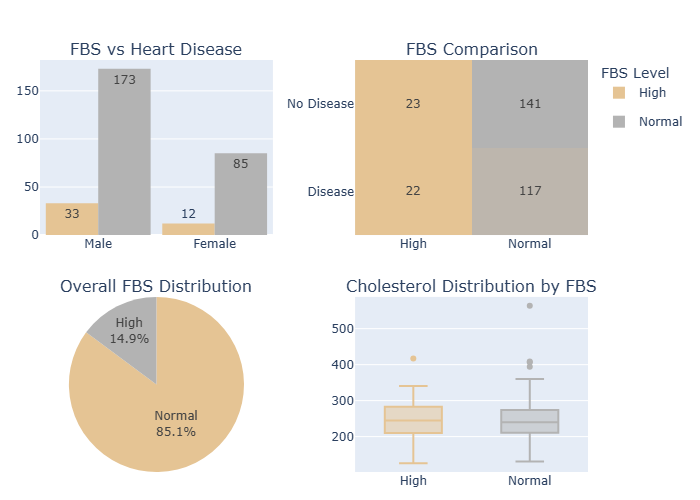

In [23]:
# --- Data Preparation ---
colors = ['#e5c494', '#b3b3b3']
fbs_counts = pd.crosstab(df['disease_status'], df['fbs_label'])
fbs_counts_pie = df['fbs_label'].value_counts().reset_index()
fbs_labels = df['fbs_label'].unique()
fbs_color_map = {fbs_labels[i]: colors[i] for i in range(len(fbs_labels))}

# --- Figure Setup ---
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=("FBS vs Heart Disease", 
                                    "FBS Comparison",
                                    "Overall FBS Distribution", 
                                    "Cholesterol Distribution by FBS"),
                    specs=[[{}, {}], [{"type": "pie"}, {}]],
                    horizontal_spacing=0.15, vertical_spacing=0.15)

# 1. Grouped Histogram 
fig1 = px.histogram(df, x="sex_label", color="fbs_label", barmode="group",
                    color_discrete_map=fbs_color_map, text_auto=True)
for t in fig1.data:
    fig.add_trace(t, row=1, col=1)

# 2. Heatmap
fig2 = px.imshow(fbs_counts, text_auto=True)
fig.add_trace(fig2.update_traces(coloraxis=None, 
                                 colorscale=[[0, colors[0]], [1, colors[1]]],
                                 showscale=False).data[0], 
                                 row=1, col=2)

# 3. Pie Chart
fig3 = px.pie(fbs_counts_pie, names='fbs_label', values='count')
for t in fig3.data:
    t.update(textinfo='label+percent', marker_colors=colors, showlegend=False)
    fig.add_trace(t, row=2, col=1)

# 4. Box Plot
fig4 = px.box(df, x="fbs_label", y="chol", color="fbs_label", 
              color_discrete_map=fbs_color_map)
for t in fig4.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=2, col=2)

# --- Final Layout ---
fig.update_layout(height=800, width=1200, bargap=0.1,
                  margin=dict(l=40, r=20, t=60, b=20),
                  legend_title_text="FBS Level")
fig.show()

- The vast majority of patients (85.1%) have normal fasting `blood sugar` levels, while only 14.9% have high FBS (above 120 mg/dL), indicating that diabetes or pre-diabetes is relatively uncommon in this dataset.

- High FBS shows nearly equal distribution between diseased (22) and healthy (23) patients, suggesting elevated `blood sugar` alone isn't a strong indicator of heart disease in this population.
- Among both diseased and healthy groups, most patients maintain normal FBS levels (117 diseased, 141 healthy).

- Males show higher rates of elevated FBS (33 high vs 173 normal) compared to females (12 high vs 85 normal).
- However, the proportions are similar across genders (roughly 15-16% have high FBS), so the absolute difference is mainly due to more males in the dataset.

- The box plot reveals that patients with high FBS tend to have slightly higher median cholesterol (around 250-260) compared to normal FBS patients (around 240).
- Both groups show similar spreads and ranges (roughly 150-350 mg/dL), with a few outliers reaching 400-550.

- Fasting `blood sugar` appears to be a weak predictor of heart disease in this dataset, as high FBS patients are almost equally split between diseased and healthy groups. Most patients maintain normal `blood sugar` regardless of heart disease status.

### Slope

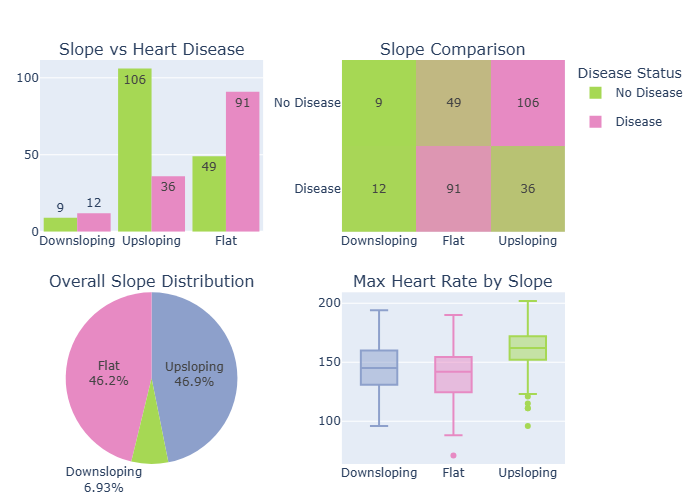

In [24]:
# --- Data Preparation ---
colors = px.colors.qualitative.Set2[2::]
disease_colors = ['#a6d854','#e78ac3']
slope_counts = pd.crosstab(df['disease_status'], df['slope_label'])
slope_counts_pie = df['slope_label'].value_counts().reset_index()
disease_labels = df['disease_status'].unique()
disease_color_map = {disease_labels[i]: disease_colors[i] for i in range(len(disease_labels))}

# --- Figure Setup ---
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=("Slope vs Heart Disease", 
                                    "Slope Comparison",
                                    "Overall Slope Distribution", 
                                    "Max Heart Rate by Slope"),
                    specs=[[{}, {}], [{"type": "pie"}, {}]],
                    horizontal_spacing=0.15, vertical_spacing=0.15)

# 1. Grouped Histogram 
fig1 = px.histogram(df, x="slope_label", color="disease_status", barmode="group",
                    color_discrete_map=disease_color_map, text_auto=True)
for t in fig1.data:
    fig.add_trace(t, row=1, col=1)

# 2. Heatmap
fig2 = px.imshow(slope_counts, text_auto=True)
fig.add_trace(fig2.update_traces(coloraxis=None, 
                                 colorscale=[[0, disease_colors[0]], [1, disease_colors[1]]],
                                 showscale=False).data[0], 
              row=1, col=2)

# 3. Pie Chart
fig3 = px.pie(slope_counts_pie, names='slope_label', values='count')
for t in fig3.data:
    t.update(textinfo='label+percent', marker_colors=colors[:len(slope_counts_pie)], showlegend=False)
    fig.add_trace(t, row=2, col=1)

# 4. Box Plot
fig4 = px.box(df, x="slope_label", y="thalach", color="slope_label", 
              color_discrete_sequence=colors)
for t in fig4.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=2, col=2)

# --- Final Layout ---
fig.update_layout(height=800, width=1200, bargap=0.1,
                  margin=dict(l=40, r=20, t=60, b=20),
                  legend_title_text="Disease Status")
fig.show()

- The dataset is almost evenly split between `upsloping` (46.9%) and `flat` (46.2%) ST segments, with only 6.9% showing downsloping. This suggests most patients fall into two main categories.

- `Flat` slope shows a strong association with heart disease: 91 diseased vs only 49 healthy patients. This makes it the strongest disease indicator among the three slope types.
- `Upsloping` slope shows the opposite pattern: 106 healthy vs only 36 diseased, suggesting it's associated with better heart health.
- `Downsloping` is relatively rare (21 total cases) but shows slightly more disease cases (12) than healthy ones (9).

- The comparison clearly shows that healthy patients predominantly have `upsloping` slopes (106 out of 164), while diseased patients cluster around `flat` slopes (91 out of 139).
- This creates a distinct pattern where slope type can be a useful predictor of disease status.

- Patients with `upsloping` slopes have notably higher maximum heart rates (median around 160-165 bpm) compared to `flat` (median around 140) or downsloping (median around 145).
- The `upsloping` group shows the widest range and highest values, reaching up to 200 bpm, while `flat` and downsloping groups are more constrained.

- ST segment slope appears to be a valuable indicator: `flat` slopes strongly suggest heart disease, while `upsloping` slopes indicate healthier hearts. The connection with maximum heart rate suggests `upsloping` patients can achieve better exercise capacity.

### Other measures

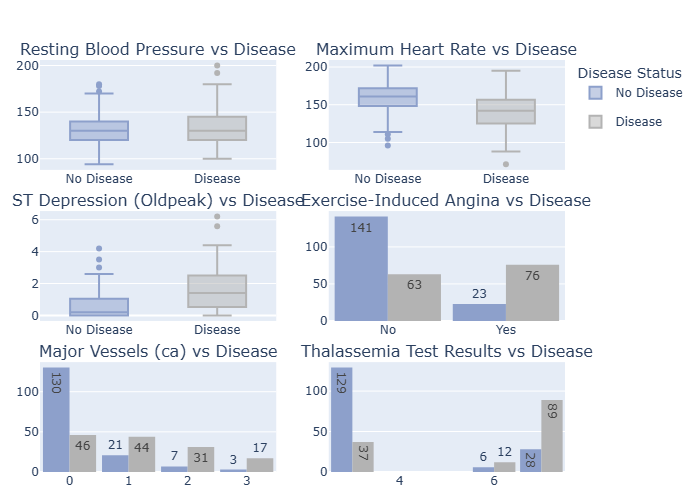

In [25]:
# --- Data Preparation ---
colors = [ '#8da0cb', '#b3b3b3']
disease_colors = colors[:2] 
disease_labels = df['disease_status'].unique()
disease_color_map = {disease_labels[i]: disease_colors[i] for i in range(len(disease_labels))}

# --- Figure Setup ---
fig = make_subplots(rows=3, cols=2, 
                    subplot_titles=("Resting Blood Pressure vs Disease", 
                                    "Maximum Heart Rate vs Disease",
                                    "ST Depression (Oldpeak) vs Disease", 
                                    "Exercise-Induced Angina vs Disease",
                                    "Major Vessels (ca) vs Disease", 
                                    "Thalassemia Test Results vs Disease"),
                    specs=[[{}, {}] for _ in range(3)],
                    vertical_spacing=0.1, horizontal_spacing=0.1)

# Row 1, Col 1: Resting Blood Pressure
fig1 = px.box(df, x="disease_status", y="trestbps", color="disease_status",
              color_discrete_map=disease_color_map)
for t in fig1.data:
    fig.add_trace(t, row=1, col=1)

# Row 1, Col 2: Max Heart Rate
fig2 = px.box(df, x="disease_status", y="thalach", color="disease_status", 
              color_discrete_map=disease_color_map)
for t in fig2.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=1, col=2)

# Row 2, Col 1: Oldpeak
fig3 = px.box(df, x="disease_status", y="oldpeak", color="disease_status", 
              color_discrete_map=disease_color_map)
for t in fig3.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=2, col=1)

# Row 2, Col 2: Exercise-Induced Angina
fig4 = px.histogram(df, x="exang_label", color="disease_status", barmode="group",
                    color_discrete_map=disease_color_map, text_auto=True)
for t in fig4.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=2, col=2)

# Row 3, Col 1: Major Vessels
fig5 = px.histogram(df, x="ca", color="disease_status", barmode="group",
                    color_discrete_map=disease_color_map, text_auto=True)
for t in fig5.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=3, col=1)

# Row 3, Col 2: Thal
fig6 = px.histogram(df, x="thal", color="disease_status", barmode="group",
                    color_discrete_map=disease_color_map, text_auto=True)
for t in fig6.data:
    t.update(showlegend=False)
    fig.add_trace(t, row=3, col=2)

# --- Final Layout ---
fig.update_layout(height=1000, width=1200, bargap=0.1,
                  legend_title_text="Disease Status",
                  margin=dict(l=40, r=20, t=60, b=20))
fig.show()

**Resting Blood Pressure:**
- Shows minimal difference between healthy and diseased patients, with both groups clustering around 120-140 mmHg (medians around 130).
- Both groups have similar ranges and spreads, suggesting resting `blood pressure` alone isn't a strong disease predictor in this dataset.

**Maximum Heart Rate:**
- Clear difference: healthy patients achieve higher maximum `heart rates` (median around 160 bpm) compared to diseased patients (median around 140 bpm).
- This 20 bpm difference suggests reduced exercise capacity in diseased patients, making this a potentially useful indicator.

**ST Depression (Oldpeak):**
- Diseased patients show notably higher `ST depression` values (median around 1.5-2.0) compared to healthy patients (median close to 0).
- Healthy patients cluster near zero, while diseased patients spread across 0-4 range, indicating this is a strong disease marker.

**Exercise-Induced Angina:**
- Strong pattern: most healthy patients don't experience `exercise-induced chest pain` (141 no vs 23 yes), while diseased patients show the opposite (63 no vs 76 yes).
- More than half of diseased patients experience `angina` during exercise, making this a significant symptom.

**Major Vessels (ca):**
- Healthy patients predominantly have zero `blocked vessels` (130 out of 164), while diseased patients show more varied blockages.
- As blockage count increases (1, 2, 3 `vessels`), the proportion of diseased patients rises, with 2-3 `blocked vessels` strongly indicating disease.

**Thalassemia Test Results:**
- Most patients score 3 or 7 on this test. Healthy patients cluster at value 3 (129 patients), while diseased patients spread more across values, with notable counts at 3, 7, and some at 6.
- Value 7 shows the highest disease count (89), suggesting abnormal results correlate with heart disease.

**Conclusion:**
- The strongest disease indicators appear to be: lower maximum `heart rate`, higher `ST depression`, presence of `exercise-induced angina`, and increased number of `blocked vessels`. Resting `blood pressure` shows surprisingly little difference between groups.

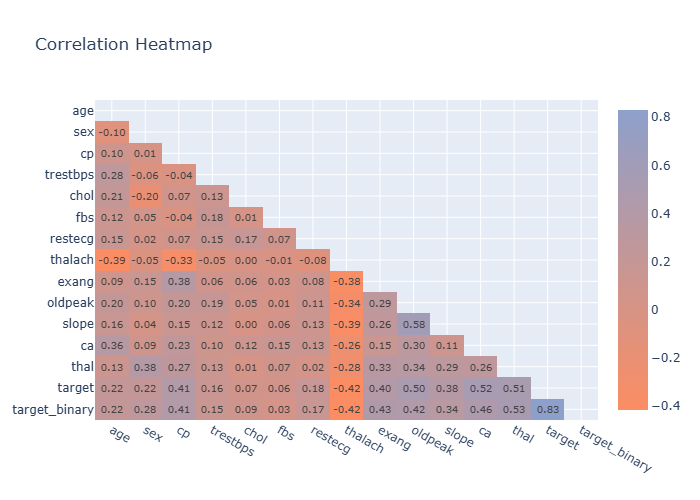

In [26]:
# Correlation heatmap

corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
corr_masked = corr.mask(mask)
fig = px.imshow(corr_masked, text_auto='.2f',color_continuous_scale=px.colors.qualitative.Set2[1:3],
                title="Correlation Heatmap", aspect="auto",
                width=1000, height=650)
fig.show()

**Strong Positive Correlations:**
- `Slope` and `oldpeak` (0.58) - patients with higher ST depression tend to have different slope patterns.
- `Slope` and `target` (0.50) - ST segment slope strongly correlates with disease presence.
- `CA` (blocked vessels) and `target` (0.52) - more blocked vessels correlate with disease.
- `Thal` (thalassemia results) and `target` (0.51) - abnormal test results correlate with disease.

**Strong Negative Correlations:**
- `Maximum heart rate` (thalach) and `target` (-0.42) - diseased patients achieve lower maximum heart rates, confirming earlier observations.
- `Maximum heart rate` and `age` (-0.39) - older patients have lower maximum heart rates, which is expected.
- `Maximum heart rate` and `exercise-induced angina` (-0.38) - patients with angina reach lower heart rates.
- `Maximum heart rate` and `oldpeak` (-0.34) - lower heart rates associate with higher ST depression.

**Key Feature Importance for Prediction:**
The strongest predictors of heart disease appear to be: `slope` (0.50), `CA` (0.52), `thal` (0.51), `oldpeak` (0.43), and `exercise-induced angina` (0.40), while traditional risk factors like `cholesterol` and `blood pressure` show weak correlations.

# <span style='color:#a6d854'>**Statistical Tests**</span>


In [27]:
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import lilliefors
import pingouin as pg
import scikit_posthocs as sp

from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multitest import multipletests
from sklearn.utils import resample
from statsmodels.stats.outliers_influence import variance_inflation_factor


### <span style='color:#e5c494'>**Normality Test**</span>
- Is the `age` column normally distributed?

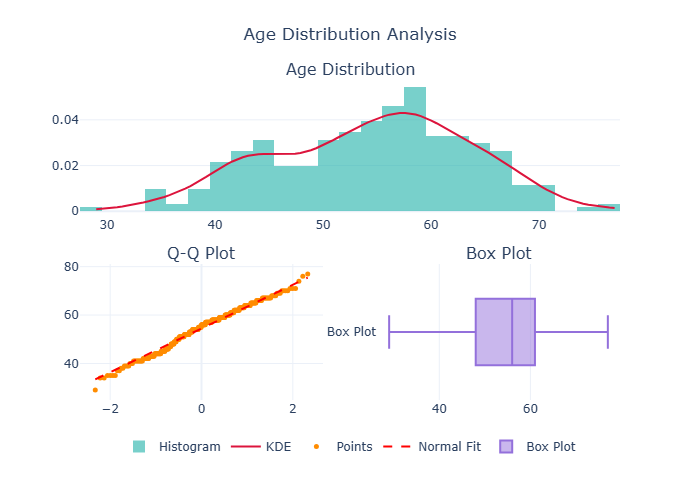

In [28]:
# Setup Subplots
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"colspan": 2}, None], [{}, {}]],
    subplot_titles=('Age Distribution', 'Q-Q Plot', 'Box Plot'),
    vertical_spacing=0.15
)

# Histogram + KDE
fig.add_trace(go.Histogram(
    x=df['age'], nbinsx=30, name='Histogram',
    marker_color='lightseagreen', opacity=0.6, histnorm='probability density'
), row=1, col=1)

kde_x = np.linspace(df['age'].min(), df['age'].max(), 100)
kde_y = stats.gaussian_kde(df['age'])(kde_x)
fig.add_trace(go.Scatter(
    x=kde_x, y=kde_y, mode='lines', name='KDE',
    line=dict(color='crimson', width=2)
), row=1, col=1)

# Bottom Left: Q-Q Plot
sorted_age = np.sort(df['age'])
theo_q = stats.norm.ppf(np.linspace(0.01, 0.99, len(sorted_age)))
mu, sigma = df['age'].mean(), df['age'].std()

fig.add_trace(go.Scatter(
    x=theo_q, y=sorted_age, mode='markers', name='Points',
    marker=dict(color='darkorange', size=5)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=theo_q, y=theo_q * sigma + mu, mode='lines', name='Normal Fit',
    line=dict(color='red', dash='dash')
), row=2, col=1)

# Bottom Right: Box Plot
fig.add_trace(go.Box(
    x=df['age'], name='Box Plot', marker_color='mediumpurple'
), row=2, col=2)

# Layout
fig.update_layout(
    title='Age Distribution Analysis',
    title_x=0.5,
    height=800, width=1000,
    template='plotly_white',
    margin=dict(t=80, b=100), 
    legend=dict(
        orientation="h",
        yanchor="top", 
        y=-0.1,  # Move below the chart
        xanchor="center", 
        x=0.5
    )
)

fig.show()

In [29]:
# Shapiro-Wilk Test
shapiro_age_stat, shapiro_age_p_value = stats.shapiro(df['age'])
print(f"Shapiro-Wilk Test Statistic: {shapiro_age_stat:.3f}, P-value: {shapiro_age_p_value:.3f}")

# Anderson-Darling Test
anderson_result = stats.anderson(df['age'])
print(f"\nAnderson-Darling Test Statistic: {anderson_result.statistic:.3f}")
print("Critical Values:", anderson_result.critical_values)
print("Significance Levels:", anderson_result.significance_level)
# If statistic > critical_value at a given level → reject normality

# Kolmogorov-Smirnov Test (compares to standard normal)
ks_stat, ks_p = stats.kstest((df['age'] - df['age'].mean())/df['age'].std(ddof=0), 'norm')
print(f"\nKolmogorov-Smirnov Test: statistic={ks_stat:.3f}, p-value={ks_p:.3f}")

# D’Agostino and Pearson’s Test
dag_stat, dag_p = stats.normaltest(df['age'])
print(f"\nD’Agostino and Pearson’s Test: statistic={dag_stat:.3f}, p-value={dag_p:.3f}")

# Lilliefors Test (variant of KS test for estimated mean/std)
lillie_stat, lillie_p = lilliefors(df['age'])
print(f"\nLilliefors Test: statistic={lillie_stat:.3f}, p-value={lillie_p:.3f}")

# Jarque–Bera Test (focuses on skewness & kurtosis)
jb_stat, jb_p = stats.jarque_bera(df['age'])
print(f"\nJarque–Bera Test: statistic={jb_stat:.3f}, p-value={jb_p:.3f}")

# Shapiro-Francia Test (better for larger samples)
sf = pg.normality(df['age'], method='shapiro')
print("\nShapiro-Francia Test:\n", sf)


Shapiro-Wilk Test Statistic: 0.986, P-value: 0.006

Anderson-Darling Test Statistic: 1.517
Critical Values: [0.569 0.648 0.777 0.906 1.078]
Significance Levels: [15.  10.   5.   2.5  1. ]

Kolmogorov-Smirnov Test: statistic=0.077, p-value=0.052

D’Agostino and Pearson’s Test: statistic=8.243, p-value=0.016

Lilliefors Test: statistic=0.077, p-value=0.001

Jarque–Bera Test: statistic=5.792, p-value=0.055

Shapiro-Francia Test:
             W      pval  normal
age  0.986463  0.006069   False


In [30]:
# Skewness and Kurtosis
skew = stats.skew(df['age'])
kurt = stats.kurtosis(df['age'])
print(f"Skewness: {skew:.3f}, Kurtosis: {kurt:.3f}")

Skewness: -0.208, Kurtosis: -0.535


* Most tests indicate that **age is not normally distributed** (p < 0.05). The Jarque–Bera result is borderline, suggesting that the deviations come mainly from **mild skewness or kurtosis** rather than a major violation.

* **Visual checks** (histogram and Q–Q plot) show that the distribution is **roughly normal** with slight tail departures.

* If strict normality is required, we may consider **transformations** or use **non-parametric methods** instead.


### <span style='color:#e5c494'>**Mean Comparison (Independent Samples)**</span>

#### <span style='color:#e18c0c'>**T-test**</span>

- Is there a significant difference in the average **age** between male and female patients?

In [31]:
# Levene's Test 

male_age = df[df['sex'] == 1]['age']
female_age = df[df['sex'] == 0]['age']

stat_levene_eq, p_levene_eq = stats.levene(male_age, female_age)
print(f"Levene Test: P-value = {p_levene_eq:.3f}")

Levene Test: P-value = 0.553


In [32]:
# Perform the t-test
t_stat, p_value = stats.ttest_ind(male_age, female_age, equal_var=True)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -1.70
P-value: 0.0901


The obtained p-value is greater than 0.05, which means there is `no statistically significant difference` in the average age between male and female patients.

#### <span style='color:#e18c0c'>**Mann-Whitney U Test**</span>

- Is there a significant difference in the distribution of cholesterol levels between male and female patients?

In [33]:
male_chol = df[df['sex'] == 1]['chol']
female_chol = df[df['sex'] == 0]['chol']

# Perform the Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(male_chol, female_chol)

print(f"Mann-Whitney U statistic: {u_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# A low p-value (e.g., < 0.05) suggests that the distributions are different.

Mann-Whitney U statistic: 8082.00
P-value: 0.0073


- There is a statistically significant difference between the two groups’ distributions.

- Since the Mann–Whitney U test is non-parametric, this means that the medians (or overall distributions) of the two groups are not equal.

- The Mann–Whitney U test indicated a significant difference between the two groups (U = 8082.00, p = 0.0073).

In [34]:
# Group Comparisons (Heart Disease target: 0 vs 1+)

for col in ["age", "trestbps", "chol", "thalach", "oldpeak"]:
    # 1. Define the two groups
    group0 = df[df['target_binary'] == 0][col].dropna()
    group1 = df[df['target_binary'] == 1][col].dropna()

    print(f"\n--- {col.upper()} ---")

    # 2. Student's T-Test and Cohen's d (Effect Size)
    ttest_results = pg.ttest(group0, group1, paired=False, correction=True)
    
    T = ttest_results['T'].iloc[0]
    P_val_T = ttest_results['p-val'].iloc[0]
    D = ttest_results['cohen-d'].iloc[0]
    
    print(f"T-Test: T={T:.3f}, P={P_val_T:.4f}, Cohen's d={D:.3f}")
    
    # 3. Mann-Whitney U Test (Non-parametric)
    mw_test = stats.mannwhitneyu(group0, group1)
    
    print(f"Mann-Whitney U: U={mw_test.statistic:.1f}, P={mw_test.pvalue:.4f}")

    # 4. Levene's Test (Are Variances Equal?)
    levene_test = stats.levene(group0, group1)

    print(f"Levene's Test: F={levene_test.statistic:.3f}, P={levene_test.pvalue:.4f}")

    # Interpretation Line
    if P_val_T < 0.05:
        print("-> Significant difference in means (P < 0.05).")
    else:
        print("-> No significant difference in means (P >= 0.05).")


--- AGE ---
T-Test: T=-4.030, P=0.0001, Cohen's d=0.458
Mann-Whitney U: U=8274.5, P=0.0000
Levene's Test: F=7.936, P=0.0052
-> Significant difference in means (P < 0.05).

--- TRESTBPS ---
T-Test: T=-2.615, P=0.0094, Cohen's d=0.305
Mann-Whitney U: U=9710.0, P=0.0260
Levene's Test: F=2.000, P=0.1583
-> Significant difference in means (P < 0.05).

--- CHOL ---
T-Test: T=-1.492, P=0.1366, Cohen's d=0.171
Mann-Whitney U: U=9798.5, P=0.0354
Levene's Test: F=0.145, P=0.7032
-> No significant difference in means (P >= 0.05).

--- THALACH ---
T-Test: T=7.858, P=0.0000, Cohen's d=0.918
Mann-Whitney U: U=16989.5, P=0.0000
Levene's Test: F=5.222, P=0.0230
-> Significant difference in means (P < 0.05).

--- OLDPEAK ---
T-Test: T=-7.823, P=0.0000, Cohen's d=0.938
Mann-Whitney U: U=6037.0, P=0.0000
Levene's Test: F=33.000, P=0.0000
-> Significant difference in means (P < 0.05).


- `Age`, `trestbps`, `thalach`, and `oldpeak` show clear and statistically strong differences between patients with and without `heart-disease`.
  
- `Thalach` and `oldpeak` have the largest effect sizes (Cohen’s d ≈ 0.9), indicating strong practical differences.
  
- `Cholesterol` does not differ in mean values, though Mann-Whitney suggests a small distribution shift with low effect size.
  
- Levene’s test shows unequal variances for age, `thalach`, and `oldpeak`, but not for `trestbps` or `cholesterol`.
  
- Overall, `heart-disease` patients tend to be older, have higher resting BP and `oldpeak`, and lower `thalach`.


#### <span style='color:#e18c0c'>**Chi-Square Test**</span>

- Is there a relationship between gender (`sex`) and the presence of **heart disease**?

In [35]:
df['target_binary'].value_counts()

target_binary
0    164
1    139
Name: count, dtype: int64

In [36]:
# Contingency table
contingency_table = pd.crosstab(df['sex'], df['target_binary'])

# The chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.4f}")


Chi-square statistic: 22.04
P-value: 0.0000


- There is a strong statistical relationship between gender and heart disease (p < 0.0001). Males are significantly more likely to have heart disease than females in this dataset, confirming the patterns we saw earlier in the visualizations.

In [37]:
# Categorical Associations

def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.values.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Handle the case where r or k is 1 (which shouldn't happen with crosstab on meaningful data)
    denominator = min(k - 1, r - 1)
    if denominator == 0:
        return np.nan
    return np.sqrt(phi2 / denominator)

for col in ["sex", "fbs", "exang", "restecg", "slope", "ca", "thal"]:
    # 1. Create the Contingency Table
    table = pd.crosstab(df[col], df['target_binary'])
    
    # 2. Run Chi-square Test
    chi2, p, dof, expected = stats.chi2_contingency(table)
    
    print(f"\n--- {col.upper()} vs TARGET (Heart Disease) ---")
    
    # Print formatted Chi-square Results
    print(f"Chi-square: Stat={chi2:.3f}, P-value={p:.4f}, DF={dof}")
    
    # Interpretation of P-value
    if p < 0.05:
        print("-> Significant relationship (P < 0.05).")
    else:
        print("-> No significant relationship (P >= 0.05).")
    
    # 3. Print Fisher's Exact Test (Only for 2x2 tables)
    if table.shape == (2, 2):
        odds_ratio, fisher_p = stats.fisher_exact(table)
        print(f"Fisher's Exact: Odds Ratio={odds_ratio:.3f}, P-value={fisher_p:.4f}")

    # 4. Print Cramér’s V (Strength of Relationship)
    v = cramers_v(table)
    print(f"Cramér’s V (Strength): {v:.3f}")
    
    # Interpretation of V (Optional, but helpful)
    if v < 0.1:
        print("   (Very weak association)")
    elif v < 0.3:
        print("   (Weak to moderate association)")
    elif v < 0.5:
        print("   (Moderate to strong association)")
    else:
        print("   (Strong association)")


--- SEX vs TARGET (Heart Disease) ---
Chi-square: Stat=22.043, P-value=0.0000, DF=1
-> Significant relationship (P < 0.05).
Fisher's Exact: Odds Ratio=3.569, P-value=0.0000
Cramér’s V (Strength): 0.270
   (Weak to moderate association)

--- FBS vs TARGET (Heart Disease) ---
Chi-square: Stat=0.077, P-value=0.7813, DF=1
-> No significant relationship (P >= 0.05).
Fisher's Exact: Odds Ratio=1.153, P-value=0.7463
Cramér’s V (Strength): 0.016
   (Very weak association)

--- EXANG vs TARGET (Heart Disease) ---
Chi-square: Stat=54.686, P-value=0.0000, DF=1
-> Significant relationship (P < 0.05).
Fisher's Exact: Odds Ratio=7.395, P-value=0.0000
Cramér’s V (Strength): 0.425
   (Moderate to strong association)

--- RESTECG vs TARGET (Heart Disease) ---
Chi-square: Stat=10.052, P-value=0.0066, DF=2
-> Significant relationship (P < 0.05).
Cramér’s V (Strength): 0.182
   (Weak to moderate association)

--- SLOPE vs TARGET (Heart Disease) ---
Chi-square: Stat=45.785, P-value=0.0000, DF=2
-> Signifi

- Strongest associations with heart disease are `thal`, `ca`, `exang`, and `slope`, with Cramér’s V in the moderate-to-strong or strong range.

- `sex` shows a significant but weaker association (V ≈ 0.27).

- `restecg` has a small but significant association.

- `fbs` shows no meaningful or significant relationship.

- Overall, structural heart indicators (`ca`, `thal`), exercise-related responses (`exang`, `slope`), and `sex` are the most informative categorical predictors.

#### <span style='color:#e18c0c'>**Pearson and Spearman Correlation**</span>

- Is there a linear relationship between **age** and **maximum heart rate achieved (`thalach`)**?

In [38]:
# Pearson Correlation 
pearson_corr, pearson_p_value = stats.pearsonr(df['age'], df['thalach'])

print(f"Pearson Correlation Coefficient: {pearson_corr:.2f}")
print(f"Pearson P-value: {pearson_p_value:.4f}")

# Spearman Correlation 
spearman_corr, spearman_p_value = stats.spearmanr(df['age'], df['thalach'])

# Kendall’s Tau correlation
print("\nKendall’s Tau")
k_t = stats.kendalltau(df['age'], df['thalach'])
print(f"P-value: {k_t[1]:.2f}")

print(f"\nSpearman Correlation Coefficient: {spearman_corr:.2f}")
print(f"Spearman P-value: {spearman_p_value:.4f}")

Pearson Correlation Coefficient: -0.39
Pearson P-value: 0.0000

Kendall’s Tau
P-value: 0.00

Spearman Correlation Coefficient: -0.39
Spearman P-value: 0.0000


- There is a significant moderate negative correlation between age and maximum heart rate, r( n – 2 ) = –0.39, p < 0.001.
- As age increases, maximum heart rate decreases. The identical Pearson and Spearman values suggest this relationship is linear and not affected by outliers or non-normality.

In [39]:
# Correlation Test for continuous variables

cont_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]
print("\n--- Pearson Correlation ---")
print(df[cont_vars].corr(method='pearson'))

print("\n--- Spearman Correlation ---")
print(df[cont_vars].corr(method='spearman'))

print("\nPoint-Biserial correlation (target vs age):")
p_b = stats.pointbiserialr(df['target_binary'], df['age'])
print(f"p-value: {p_b[1]:.3f}")


--- Pearson Correlation ---
               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.284946  0.208950 -0.393806  0.203805
trestbps  0.284946  1.000000  0.130120 -0.045351  0.189171
chol      0.208950  0.130120  1.000000 -0.003432  0.046564
thalach  -0.393806 -0.045351 -0.003432  1.000000 -0.343085
oldpeak   0.203805  0.189171  0.046564 -0.343085  1.000000

--- Spearman Correlation ---
               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.292183  0.191253 -0.391633  0.259895
trestbps  0.292183  1.000000  0.135837 -0.040401  0.150192
chol      0.191253  0.135837  1.000000 -0.038301  0.034359
thalach  -0.391633 -0.040401 -0.038301  1.000000 -0.431510
oldpeak   0.259895  0.150192  0.034359 -0.431510  1.000000

Point-Biserial correlation (target vs age):
p-value: 0.000


- Correlations among clinical variables are generally small to moderate.

- `age` correlates moderately with `thalach` (negative) and weakly with `trestbps` and oldp`eak.

- `thalach` and `oldpeak` show the strongest inverse relationship in the matrix.

- `Cholesterol` shows almost no meaningful correlation with other variables.

- Spearman patterns match Pearson, confirming monotonic but modest relationships.

- The point-biserial correlation shows age is positively and significantly related to heart-disease presence, though the effect size is small to moderate.

### <span style='color:#e5c494'>**ANOVA (Analysis of Variance)**</span>

#### <span style='color:#e18c0c'>**One-Way ANOVA**</span>
- Is there a significant difference in average cholesterol (`chol`) across the different **chest pain types (`cp`)**

In [40]:
# Get cholesterol values for each chest pain group
chol_group_1 = df[df['cp'] == 1]['chol']
chol_group_2 = df[df['cp'] == 2]['chol']
chol_group_3 = df[df['cp'] == 3]['chol']
chol_group_4 = df[df['cp'] == 4]['chol']

# Perform the ANOVA test
f_stat, p_value = stats.f_oneway(chol_group_1, chol_group_2, chol_group_3,chol_group_4)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 0.62
P-value: 0.6007


- There is no statistically significant difference in the mean cholesterol levels among the 4 groups.
- The high p-value indicates cholesterol levels are similar regardless of chest pain type, consistent with the heatmap showing cholesterol values ranging narrowly from 229-263 across all groups.

- In other words, ANOVA did not find evidence that at least one group mean is different from the others.

#### <span style='color:#e18c0c'>**Kruskal-Wallis H Test**</span>

- Is there a significant difference in the distribution of resting heart rates (`trestbps`) across the different **chest pain types (`cp`)**?

In [41]:
# Test overall normality for continuous variables
variables = ['trestbps', 'age', 'chol']

for var in variables:
    stat, p = stats.shapiro(df[var]) # Shapiro-Wilk Test
    is_normal = "✓ Normal" if p > 0.05 else "✗ Not Normal"
    print(f"{var:10s}: p-value = {p:.4f} ({is_normal})")

trestbps  : p-value = 0.0000 (✗ Not Normal)
age       : p-value = 0.0061 (✗ Not Normal)
chol      : p-value = 0.0000 (✗ Not Normal)


In [42]:
# Kruskal-Wallis test for all variables across chest pain types
for var in variables:
    groups = [df[df['cp_label'] == label][var] for label in df['cp_label'].unique()]
    h_stat, p_value = stats.kruskal(*groups)
    significant = "✓ Significant" if p_value < 0.05 else "✗ Not Significant"
    print(f"{var:10s}: H-statistic = {h_stat:6.2f}, P-value = {p_value:.4f} ({significant})")


trestbps  : H-statistic =   7.80, P-value = 0.0504 (✗ Not Significant)
age       : H-statistic =  11.62, P-value = 0.0088 (✓ Significant)
chol      : H-statistic =   2.50, P-value = 0.4749 (✗ Not Significant)


- `Trestbps`: The result is **marginally non-significant**. With p = 0.0504, we fail to reject the null hypothesis at the 0.05 level. This indicates insufficient evidence to conclude that the groups differ in their distributions.

- `Age`: Significant difference across chest pain types (p = 0.0088). Different chest pain types are associated with different age distributions. Post-hoc testing needed to identify which groups differ.

- `Chol`: No significant difference across chest pain types (p = 0.4749). Cholesterol levels are similar regardless of chest pain type, consistent with earlier findings.

- We will proceed with post-hoc tests to further explore potential group differences.


#### <span style="color:#e18c0c">**Dunn's Test**</span>


In [43]:
# Perform the Dunnett's test

for var in ['trestbps', 'age']:
    posthoc = sp.posthoc_dunn(df, val_col=var, group_col='cp_label', p_adjust='bonferroni').round(3)
    print(f"\nPOST-HOC DUNN'S TEST FOR {var}:")
    print("="*70)
    print(posthoc)


POST-HOC DUNN'S TEST FOR trestbps:
                  asymptomatic  atypical angina  non-anginal pain  \
asymptomatic             1.000            0.821             1.000   
atypical angina          0.821            1.000             1.000   
non-anginal pain         1.000            1.000             1.000   
typical angina           0.280            0.037             0.163   

                  typical angina  
asymptomatic               0.280  
atypical angina            0.037  
non-anginal pain           0.163  
typical angina             1.000  

POST-HOC DUNN'S TEST FOR age:
                  asymptomatic  atypical angina  non-anginal pain  \
asymptomatic             1.000            0.013             0.351   
atypical angina          0.013            1.000             1.000   
non-anginal pain         0.351            1.000             1.000   
typical angina           1.000            0.131             0.933   

                  typical angina  
asymptomatic               1.00

`trestbps`: Only one significant pairwise difference was found:   
- `Atypical angina vs Typical angina` (p = 0.037) - these two chest pain types have significantly different resting blood pressure distributions.  
- All other comparisons show p-values > 0.05, meaning no significant differences in resting blood pressure between those pairs.

`age`: Single significant age difference detected between `asymptomatic vs atypical angina` patients (p=0.013). No other age differences exist between chest pain type groups.

### <span style='color:#e5c494'>**Goodness-of-fit Test**</span>
#### <span style='color:#e18c0c'>**Two-Sample Kolmogorov-Smirnov (KS) Test**</span>

- Is the distribution of maximum heart rate (`thalach`) the same for people with and without heart disease?

In [44]:
# Get thalach values for each group
thalach_no_hd = df[df['target_binary'] == 0]['thalach']
thalach_with_hd = df[df['target_binary'] == 1]['thalach']

# Perform the Two-Sample KS test
ks_stat, p_value = stats.ks_2samp(thalach_no_hd, thalach_with_hd)

print(f"KS statistic: {ks_stat:.2f}")
print(f"P-value: {p_value:.4f}")


KS statistic: 0.41
P-value: 0.0000


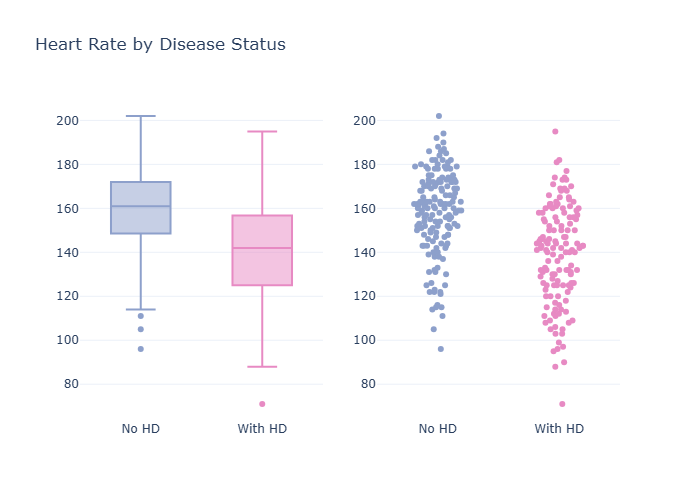

In [45]:
fig = make_subplots(rows=1, cols=2)

fig1 = px.box(df, x='target_binary', y='thalach', color='target_binary', 
              color_discrete_map={0:'#8da0cb', 1:'#e78ac3'})
fig2 = px.strip(df, x='target_binary', y='thalach', color='target_binary', 
                color_discrete_map={0:'#8da0cb', 1:'#e78ac3'})

fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_trace(fig1.data[1], row=1, col=1)
fig.add_trace(fig2.data[0].update(jitter=0.8), row=1, col=2)
fig.add_trace(fig2.data[1].update(jitter=0.8), row=1, col=2)

fig.update_layout(height=500, width=1000, template='plotly_white', showlegend=False, 
                  title_text='Heart Rate by Disease Status')
fig.update_xaxes(title_text='', ticktext=['No HD', 'With HD'], tickvals=[0, 1], row=1, col=1)
fig.update_xaxes(title_text='', ticktext=['No HD', 'With HD'], tickvals=[0, 1], row=1, col=2)
fig.show()

- The distributions of maximum heart rate `thalach` are significantly different between patients without heart disease and those with heart disease.

- This test is non-parametric, so it doesn’t assume normality—perfect for comparing distributions.

- The test showed that the distribution of maximum heart rate was significantly different between patients without and with heart disease (KS = 0.41, p < 0.001).

### <span style='color:#e5c494'>**MANOVA**</span>

Is there an **overall difference** in the set of average health indicators between patients with heart disease and patients without it?

In [46]:
# MANOVA

manova = MANOVA.from_formula('sex  + cp  + trestbps  + slope  + ca  + thal  ~ target_binary', data=df)
print("\n--- MANOVA ---")
print(manova.mv_test())


--- MANOVA ---
                   Multivariate linear model
                                                                
----------------------------------------------------------------
       Intercept         Value  Num DF  Den DF   F Value  Pr > F
----------------------------------------------------------------
          Wilks' lambda  0.0223 6.0000 290.0000 2120.9375 0.0000
         Pillai's trace  0.9777 6.0000 290.0000 2120.9375 0.0000
 Hotelling-Lawley trace 43.8815 6.0000 290.0000 2120.9375 0.0000
    Roy's greatest root 43.8815 6.0000 290.0000 2120.9375 0.0000
----------------------------------------------------------------
                                                                
----------------------------------------------------------------
        target_binary      Value  Num DF  Den DF  F Value Pr > F
----------------------------------------------------------------
             Wilks' lambda 0.5104 6.0000 290.0000 46.3624 0.0000
            Pillai's trace 0.

The MANOVA tests whether `target_binary` (heart disease vs no disease) has a joint effect on the multivariate set of predictors: `sex, cp, trestbps, slope, ca, thal`.

Key result: 
- All four multivariate tests (Wilks, Pillai, Hotelling, Roy) show **p < 0.001** for `target_binary`.
- Wilks’ lambda = **0.5104**, meaning about **49% of the variance** in the combined predictors is explained by group differences.

Interpretation
- The two groups (disease vs no disease) differ **significantly** on the **combined** profile of predictors.
- This indicates meaningful multivariate separation between the groups based on sex, chest pain type, resting blood pressure, slope, number of major vessels, and thal.

Conclusion: `target_binary` has a strong multivariate effect on the set of cardiovascular predictors.


In [47]:
# Permutation Test (difference in means)

def permutation_test(x, y, n=5000):
    observed_diff = np.mean(x) - np.mean(y)
    combined = np.concatenate([x, y])
    count = 0
    for _ in range(n):
        np.random.shuffle(combined)
        new_x = combined[:len(x)]
        new_y = combined[len(x):]
        if abs(np.mean(new_x) - np.mean(new_y)) >= abs(observed_diff):
            count += 1
    return count / n

p_val = permutation_test(df[df['target_binary']==0]['age'], df[df['target_binary']==1]['age'])
print("Permutation Test: Age vs Target")
print("p-value:", p_val)

Permutation Test: Age vs Target
p-value: 0.0


The result means the difference in  `average age ` between the heart disease groups is  `highly significant ` and is  `not due to random chance `.

The $P$-value of  $0.0$  (which is less than $0.05$) indicates an extremely strong evidence that the age distributions of the two groups are different.

In [48]:
# Mutual Information (nonlinear associations)

# Define predictors and target
X = df.drop(columns=['target', 'target_binary', 'disease_status', 'gender_disease'])
y = df['target_binary']

# One-hot encode all features
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# Clean the data: Drop any rows where a value is NaN
X_cleaned = X_encoded.dropna()
y_cleaned = y.loc[X_cleaned.index]

# 4. Calculate Mutual Information
mi = mutual_info_classif(
    X_cleaned, 
    y_cleaned, 
    discrete_features='auto'
)

print("\n--- Mutual Information Scores ---")
print(pd.Series(mi, index=X_cleaned.columns).sort_values(ascending=False))


--- Mutual Information Scores ---
ca                           0.153384
slope                        0.128462
thal                         0.122082
exang                        0.108963
exang_label_Yes              0.108935
cp                           0.100849
slope_label_Flat             0.081265
slope_label_Upsloping        0.079332
chol                         0.078525
oldpeak                      0.074732
thalach                      0.066752
cp_label_non-anginal pain    0.062176
sex_label_Male               0.057919
sex                          0.052737
age                          0.028404
fbs                          0.014213
fbs_label_Normal             0.011106
cp_label_atypical angina     0.007580
restecg                      0.002669
trestbps                     0.000000
cp_label_typical angina      0.000000
dtype: float64


These  `Mutual Information Scores ` show  `how much information ` each variable provides about the target variable (heart disease status). Higher scores mean a stronger relationship.

The strongest factors related to heart disease status are:

*  `Thal, CP, and CA ` ($\approx 0.14 - 0.10$): Clinical variables like  `Thal ` (Thalassemia),  `CP ` (Chest Pain type), and the number of major vessels ( `CA `) are the next most informative features.
*  `Other Key Factors ` ($\approx 0.08 - 0.05$): Indicators like  `Exang ` (Exercise-Induced Angina) and having a  `Flat ` slope on the exercise ECG also provide a good amount of information.
*  `Weakest Factors ` ($\approx 0.01 - 0.00$): Variables like  `Age `,  `Resting Blood Pressure (trestbps) `,  `Restecg `, and  `Fasting Blood Sugar (fbs) ` provide the least amount of independent information about the final heart disease status.

In [49]:
# Variance Inflation Factor (multicollinearity)

X_vif = sm.add_constant(df[['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak', 'slope','ca','thal']]).dropna()
vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n--- Variance Inflation Factor ---")
print(vif)



--- Variance Inflation Factor ---
     Feature         VIF
0      const  251.649736
1        age    1.492890
2        sex    1.304240
3         cp    1.322040
4   trestbps    1.209070
5       chol    1.137099
6        fbs    1.078260
7    restecg    1.091455
8    thalach    1.645696
9      exang    1.377849
10   oldpeak    1.759751
11     slope    1.681559
12        ca    1.350350
13      thal    1.520653


This VIF summary shows that there is no problem with multicollinearity among continuous variables.

`VIF Scores:` All the VIF scores for the predictor variables ($\text{age}$, $\text{trestbps}$, $\text{chol}$, $\text{thalach}$, $\text{oldpeak}$) are `very low` (all below 1.8).  

Conclusion: Since the scores are much less than the typical cutoff of 5, regression coefficients are `stable` and are `not inflated` (distorted) by the relationships between these variables.


### <span style='color:#e5c494'>**Logistic Regression**</span>

- Which variables are significant predictors of **heart disease**?

In [50]:
# Drop rows with missing values
df_clean = df.dropna().copy()

# Define predictors and target
X = df_clean[['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak', 'slope','ca','thal']]

y = df_clean['target_binary']

# Convert everything to numeric (fixes object dtype problems)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# One-hot encode categorical variables properly
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

df_model = pd.concat([X, y], axis=1).dropna()
y = df_model['target_binary']
X = df_model.drop(columns='target_binary')

# Ensure all columns in X are explicitly float type
X = X.astype(float) 

# Add intercept
X = sm.add_constant(X)

# Fit logistic regression
model = sm.Logit(y, X).fit()

print(model.summary())


Optimization terminated successfully.
         Current function value: 0.322630
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:          target_binary   No. Observations:                  297
Model:                          Logit   Df Residuals:                      278
Method:                           MLE   Df Model:                           18
Date:                Fri, 05 Jun 2026   Pseudo R-squ.:                  0.5325
Time:                        19:31:33   Log-Likelihood:                -95.821
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 2.124e-36
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -6.0295      2.892     -2.085      0.037     -11.697      -0.362
age            -0.0138    

The Logistic Regression model has a `good predictive power` (Pseudo $R^2 = 0.53$), showing that the model is statistically significant overall.  

The most reliable predictors for heart disease are `sex`, `ca`, `slope_2.0`, `thal_7.0`, and `cp_4.0` (asymptomatic chest pain), as their P-values are below $0.05$. Higher resting blood pressure (`trestbps`) also significantly increases the odds of heart disease. Variables like `age`, `cholesterol`, and `fbs` were found to be `not statistically significant` predictors in this model.

Conclusion: `sex`, `blood pressure`, `number of affected vessels`, `asymptomatic chest pain`, `slope_2.0 (flat)`, and `thal_7.0 (reversable defect)` are the key drivers.

In [51]:
# Export DataFrame to a CSV file
df.to_csv('heart_disease_processed.csv')

# <span style='color:#ffd92f'>**Key Insights and Findings**</span>

### Dataset Overview

* **45.87%** of patients are diagnosed with heart disease.
* The average patient age is **54.44 years**.
* The dataset is male-dominated: **68% males (206)** and **32% females (97)**.

### Gender & Age Patterns

* Males show a much higher disease rate (**55%**) compared to females (**26%**).
* Among diseased patients, **82% are male**.
* Diseased patients are generally older, concentrated in the **50–65** age range.
* There is **no significant difference** in average age between males and females.
* As age increases, **maximum heart rate decreases**.

**What we suggest**

* We should consider gender-specific risk profiling, as sex is a strong predictor in this dataset.
* Age-based screening becomes increasingly important after 50.

### Chest Pain & Clinical Indicators

* **Asymptomatic chest pain** is the most common type and is associated with a **higher disease risk**.
* Healthy patients cluster around **non-anginal** and **atypical angina** pain types.
* Significant differences exist between chest pain categories in both age and resting blood pressure.
* The strongest categorical indicators are **chest pain type (CP)**, **number of blocked vessels (CA)**, and **thalassemia (Thal)**.

**What we suggest**

* We should not treat the absence of chest pain as low risk.
* Structural and functional heart indicators deserve more weight than symptom-based assessment alone.

### Cholesterol, Blood Pressure & FBS

* Cholesterol levels show **little difference** between diseased and healthy patients.
* Females tend to have **higher cholesterol**, regardless of disease status.
* Most patients maintain **normal fasting blood sugar**, though males show higher abnormal rates.
* Resting blood pressure shows limited separation, despite statistical significance in group comparisons.

**What we suggest**

* Traditional markers like cholesterol alone are insufficient predictors in this dataset.
* Risk assessment should combine multiple clinical and structural indicators.

### Exercise Response & ECG Features

* **Flat ST slope** shows a strong association with heart disease and is the most informative slope type.
* Diseased patients exhibit:

  * Lower maximum heart rate (`thalach`)
  * Higher ST depression (`oldpeak`)
  * Higher rates of exercise-induced angina
* Delivery-related ECG features outperform resting vitals in predictive strength.

### Correlation & Statistical Findings

* Strongest correlations with heart disease:

  * `CA` (0.52), `Thal` (0.51), `Slope` (0.50)
  * `Oldpeak` (0.43), `Exercise-induced angina` (0.40)
* Cholesterol and resting blood pressure show weak correlations.
* Multivariate tests confirm **clear separation** between diseased and non-diseased patients.
* The average age difference between groups is **highly significant** and not random.

### Predictive Modeling

* The logistic regression model shows **good predictive power** (Pseudo R² = **0.53**).
* Key drivers include:

  * Sex
  * Resting blood pressure
  * Number of affected vessels
  * Asymptomatic chest pain
  * Flat ST slope
  * Reversible thal defect

**What we suggest**

* We should prioritize multivariate risk models over single-metric thresholds.
* Structural heart indicators and exercise-response features should be central in prediction systems.
